In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from escnn import gspaces
import escnn.nn as enn

/Users/aadityabhatnagar/Downloads/Development/practice/deeplense_test/code/venv/lib/python3.13/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


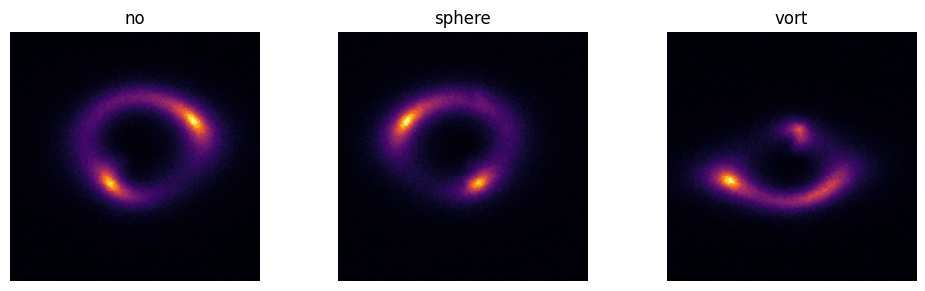

In [2]:
class_names = ["no", "sphere", "vort"]
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i, name in enumerate(class_names):
    sample = np.load(f'../dataset/train/{name}/1.npy')
    axes[i].imshow(sample[0], cmap='inferno')
    axes[i].set_title(name)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [3]:
class LensingDataset(Dataset):
    def __init__(self, img_paths, labels):
        self.img_paths = img_paths
        self.labels = labels
        
    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, index):
        image = np.load(self.img_paths[index]).astype(np.float32)
        return torch.from_numpy(image), self.labels[index]

In [4]:
class EquivariantLensClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        
        self.gspace = gspaces.rot2dOnR2(N=8)
        
        in_type = enn.FieldType(self.gspace, 1 * [self.gspace.trivial_repr])
        feat16   = enn.FieldType(self.gspace, 16 * [self.gspace.regular_repr])
        feat32   = enn.FieldType(self.gspace, 32 * [self.gspace.regular_repr])
        feat64   = enn.FieldType(self.gspace, 64 * [self.gspace.regular_repr])
        
        self.input_type = in_type
        
        self.block1 = enn.SequentialModule(
            enn.R2Conv(in_type, feat16, kernel_size=7, stride=2, padding=3, bias=False),
            enn.InnerBatchNorm(feat16),
            enn.ReLU(feat16, inplace=True)
        )
        
        self.block2 = enn.SequentialModule(
            enn.R2Conv(feat16, feat32, kernel_size=5, stride=2, padding=2, bias=False),
            enn.InnerBatchNorm(feat32),
            enn.ReLU(feat32, inplace=True)
        )

        self.block3 = enn.SequentialModule(
            enn.R2Conv(feat32, feat64, kernel_size=3, stride=2, padding=1, bias=False),
            enn.InnerBatchNorm(feat64),
            enn.ReLU(feat64, inplace=True)
        )
        
        self.gpool = enn.GroupPooling(feat64)
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),   
            nn.Flatten(),                    
            nn.Linear(64, 64), 
            nn.ReLU(),
            nn.Dropout(0.4),             
            nn.Linear(64, num_classes)      
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = enn.GeometricTensor(x, self.input_type)

        x = self.block1(x)   
        x = self.block2(x)   
        x = self.block3(x)   
        x = self.gpool(x)    
        
        return self.classifier(x.tensor)

In [ ]:
# Helper functions
def load_dataset(data_dir: str):
    img_paths, labels = [], []

    for class_idx, class_name in enumerate(['no', 'sphere', 'vort']):
        class_dir = os.path.join(data_dir, class_name)
        for fname in os.listdir(class_dir):
            if fname.endswith('.npy'):               
                img_paths.append(os.path.join(class_dir, fname))
                labels.append(class_idx)
    
    return img_paths, labels


def create_loaders(img_paths, labels, batch_size=32, seed=42):
    dataset = LensingDataset(img_paths, labels)
    indices = list(range(len(dataset)))
    
    train_idx, val_idx = train_test_split(
        indices,
        train_size=0.9,
        stratify=labels,       
        random_state=seed      
    )

    train_loader = DataLoader(
        Subset(dataset, train_idx),
        batch_size=batch_size,
        shuffle=True,          
        num_workers=4,  
        pin_memory=False
    )
    
    val_loader = DataLoader(
        Subset(dataset, val_idx),
        batch_size=batch_size,
        shuffle=False,         
        num_workers=4,
        pin_memory=False
    )
    
    return train_loader, val_loader

device = (
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cuda') if torch.cuda.is_available()         else
    torch.device('cpu')
)
print(f"Using device: {device}")

model = EquivariantLensClassifier(num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Load data
img_paths, labels = load_dataset('../dataset/train')
print(f"Total images: {len(img_paths)}")   

train_loader, val_loader = create_loaders(img_paths, labels)

# Training loop
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
best_val_loss = float('inf')
patience = 5 
patience_counter = 0

for epoch in range(50):
    model.train()       
    running_loss = 0.0

    for x, y in train_loader:
        x = x.to(device)                  
        y = y.to(device, dtype=torch.long) 

        optimizer.zero_grad()              
        logits = model(x)                  
        loss = criterion(logits, y)      
        loss.backward()                    
        optimizer.step()                   
        running_loss += loss.item()        

    train_loss = running_loss / len(train_loader) 

    model.eval()        
    val_loss   = 0.0
    all_preds  = []     
    all_targets = []    

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device, dtype=torch.long)

            logits   = model(x)
            val_loss += criterion(logits, y).item()
            probs = torch.softmax(logits, dim=1)
            all_preds.append(probs.cpu().numpy())
            all_targets.append(y.cpu().numpy())

    val_loss = val_loss / len(val_loader)
    all_preds   = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    auc_scores = [
        roc_auc_score((all_targets == c).astype(int), all_preds[:, c])
        for c in range(3)
    ]
    mean_auc = np.mean(auc_scores)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(mean_auc)
    print(f"Epoch {epoch+1:>2}/50 | train={train_loss:.4f} - val={val_loss:.4f} - AUC={mean_auc: 4f} : [no={auc_scores[0]:.3f} sphere={auc_scores[1]:.3f} vort={auc_scores[2]:.3f}]")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'test1_best.pth')
        print(f"  ✓ New best model saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

Using device: mps
Total images: 30000
Epoch  1/50 | train=1.1000 - val=1.0990 - AUC= 0.496252 : [no=0.498 sphere=0.490 vort=0.501]
  ✓ New best model saved (val_loss=1.0990)


KeyboardInterrupt: 